# CBS occupation-code model — BOW, TF-IDF, and embeddings

This notebook compares three text representations within the same hierarchical CatBoost modeling framework:

1. **Binary Bag-of-Words baseline** — represents whether each vocabulary term appears in a survey record, without counting repeated occurrences.
2. **TF-IDF baseline** — represents text using term-frequency and inverse-document-frequency weighting, giving more importance to terms that are informative across the dataset.
3. **Sentence-embedding model** — uses dense semantic embeddings generated with the multilingual Sentence Transformer model `sentence-transformers/LaBSE`. The embeddings were precomputed and stored in `survey_with_embeddings.pkl`, which was created by the script `create_survey_embeddings_pickle.py`. The script combines the relevant survey text fields, generates a fixed-length embedding vector for each record, and saves the resulting dataset with the embedding features. For convenience, the precomputed file is included with the submission, so the embedding-generation script does not need to be executed when running this notebook.

The evaluation focuses on the main business trade-off:

* **Manual tagging rate**: how many records are not automatically assigned a final code and are routed to manual review.
* **Accuracy among non-manual records**: how accurate the model is on records that it chooses to code automatically.

Because occupation codes are hierarchical, the model predicts the code level by level rather than treating each 4-digit code as a completely unrelated class. During prediction, beam search keeps several plausible candidate paths through the hierarchy instead of committing too early to a single path. Confidence thresholds are then used to decide whether the model should output a full 4-digit code or stop at a higher-level partial code such as `25XX` or `251X`. This supports conservative automation: when the model is uncertain about lower levels of the hierarchy, the prediction remains partial instead of forcing an unreliable exact code.

Structured preprocessing follows the revised feature rules: missing values in `MenahelEtMi` are encoded as `0`; `MakorSachar`, `MaamadAvoda`, and `TeudaGvoha` are treated as categorical variables; `shnotlimud` is treated as numeric; and `Gil`, `TarichHathala`. `ID` and `SemelAnafSofi` are excluded from the modeling features (see used features in the config file).


## 1. Imports and shared parameters

All capital-letter parameters and feature lists are stored in `config.py`, so the notebook and Python module use the same settings.

In [ ]:
%pip install -q -r requirements.txt

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from config import *

from modeling_utilities import (
    prepare_records_from_excel,
    load_embeddings_from_pickle_by_id,
    run_bow_baseline_cv,
    run_tfidf_baseline_cv,
    run_embedding_main_cv,
    add_interpretation_columns,
    evaluate_global_predictions,
    compare_models,
    summarize_operational_metrics,
    summarize_feature_importance,
    summarize_feature_importance_by_level,
    make_misclassification_comparison_sample,
    get_misclassification_class_comparisons,
    MODEL_FEATURES,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

In [2]:
print("Data path:", Path(DATA_PATH).resolve())
print("Embeddings path:", Path(EMBEDDINGS_PATH).resolve())
print("Model features:")
for feature in MODEL_FEATURES:
    print("-", feature)

Data path: /Users/yanadrevin/home_assignments/Central_Bureau_of_Statistics/DUMMY_DATASET.xlsx
Embeddings path: /Users/yanadrevin/home_assignments/Central_Bureau_of_Statistics/survey_with_embeddings.pkl
Model features:
- sim_l1
- sim_l2
- sim_l3
- sim_l4
- MenahelEtMi
- MakorSachar
- MaamadAvoda
- TeudaGvoha
- shnotlimud


## 2. Load data and embeddings

The embedding file is attached to the project for easy running. The script `create_survey_embeddings_pickle.py` is also included, so the embeddings can be recreated from the Excel file.

In [3]:
raw_df, records = prepare_records_from_excel(DATA_PATH, sheet_name=SHEET_NAME)

if not Path(EMBEDDINGS_PATH).exists():
    raise FileNotFoundError(
        f"{EMBEDDINGS_PATH} was not found. Place it in this folder or run create_survey_embeddings_pickle.py."
    )

embeddings = load_embeddings_from_pickle_by_id(
    EMBEDDINGS_PATH,
    records,
    id_col=ID_COL,
    embedding_col=EMBEDDING_COL,
)

print("Raw rows:", len(raw_df))
print("Model records:", len(records))
print("Embedding matrix shape:", embeddings.shape)
print("Target classes:", records[TARGET_COL].nunique())
print("Exact singleton records:", int(records["is_singleton_exact"].sum()))

display(records[[ID_COL, TARGET_COL, "is_singleton_exact"] + SELECTED_TABULAR_FEATURES].head())

Raw rows: 201
Model records: 200
Embedding matrix shape: (200, 768)
Target classes: 62
Exact singleton records: 24


,ID,SemelMishlachSofi,is_singleton_exact,MenahelEtMi,MakorSachar,MaamadAvoda,TeudaGvoha,shnotlimud
0,1.0,2120,False,3.0,1.0,1.0,6.0,22.0
1,2.0,3311,True,0.0,1.0,1.0,6.0,22.0
2,3.0,3512,False,0.0,1.0,1.0,5.0,15.0
3,4.0,5414,False,0.0,2.0,1.0,3.0,12.0
4,5.0,5322,False,0.0,1.0,1.0,4.0,14.0


## 3. Run the three models

Each model uses the same downstream CatBoost + beam-search logic. The only difference is how text similarity features `sim_l1`–`sim_l4` are created:

- BOW: binary word presence vectors;
- TF-IDF: character n-gram TF-IDF vectors;
- embeddings: precomputed sentence embeddings.

The structured features are exactly:

```python
MenahelEtMi, MakorSachar, MaamadAvoda, TeudaGvoha, shnotlimud
```



In [4]:
bow_predictions, bow_feature_importance = run_bow_baseline_cv(
    records,
    n_splits=N_SPLITS,
    thresholds=THRESHOLDS,
    min_support_for_auto=MIN_SUPPORT_FOR_AUTO,
    min_probability_margin=MIN_PROBABILITY_MARGIN,
    beam_width=BEAM_WIDTH,
    max_children_per_parent=MAX_CHILDREN_PER_PARENT,
    catboost_params=CATBOOST_PARAMS,
    random_state=RANDOM_STATE,
    return_feature_importance=True,
)
bow_predictions = add_interpretation_columns(bow_predictions)
print("BOW model finished")

BOW model finished


In [5]:
tfidf_predictions, tfidf_feature_importance = run_tfidf_baseline_cv(
    records,
    n_splits=N_SPLITS,
    thresholds=THRESHOLDS,
    min_support_for_auto=MIN_SUPPORT_FOR_AUTO,
    min_probability_margin=MIN_PROBABILITY_MARGIN,
    beam_width=BEAM_WIDTH,
    max_children_per_parent=MAX_CHILDREN_PER_PARENT,
    catboost_params=CATBOOST_PARAMS,
    random_state=RANDOM_STATE,
    return_feature_importance=True,
)
tfidf_predictions = add_interpretation_columns(tfidf_predictions)
print("TF-IDF model finished")

TF-IDF model finished


In [6]:
embedding_predictions, embedding_feature_importance = run_embedding_main_cv(
    records,
    embeddings,
    n_splits=N_SPLITS,
    thresholds=THRESHOLDS,
    min_support_for_auto=MIN_SUPPORT_FOR_AUTO,
    min_probability_margin=MIN_PROBABILITY_MARGIN,
    beam_width=BEAM_WIDTH,
    max_children_per_parent=MAX_CHILDREN_PER_PARENT,
    catboost_params=CATBOOST_PARAMS,
    random_state=RANDOM_STATE,
    return_feature_importance=True,
)
embedding_predictions = add_interpretation_columns(embedding_predictions)
print("Embedding model finished")

Embedding model finished


## 4. Main operational metrics

This is the most important table for the project.

- `manual_tagging_n` / `manual_tagging_fraction`: how many records the model refuses to auto-code.
- `accuracy_among_non_manual`: accuracy among records that were **not** routed to manual tagging.
- `errors_among_non_manual_n`: number of mistakes among auto-coded records.

In [7]:
predictions_by_model = {
    "BOW baseline": bow_predictions,
    "TF-IDF baseline": tfidf_predictions,
    "Embedding model": embedding_predictions,
}

operational_metrics = summarize_operational_metrics(predictions_by_model)

important_cols = [
    "n_samples",
    "manual_tagging_n",
    "manual_tagging_fraction",
    "non_manual_n",
    "non_manual_fraction",
    "accuracy_among_non_manual",
    "errors_among_non_manual_n",
    "mean_confidence_non_manual",
]

display(operational_metrics[important_cols].style.format({
    "manual_tagging_fraction": "{:.1%}",
    "non_manual_fraction": "{:.1%}",
    "accuracy_among_non_manual": "{:.1%}",
    "mean_confidence_non_manual": "{:.3f}",
}))

,n_samples,manual_tagging_n,manual_tagging_fraction,non_manual_n,non_manual_fraction,accuracy_among_non_manual,errors_among_non_manual_n,mean_confidence_non_manual
model,,,,,,,,
BOW baseline,200,60,30.0%,140,70.0%,83.6%,23,0.903
TF-IDF baseline,200,55,27.5%,145,72.5%,89.0%,16,0.899
Embedding model,200,78,39.0%,122,61.0%,87.7%,15,0.780


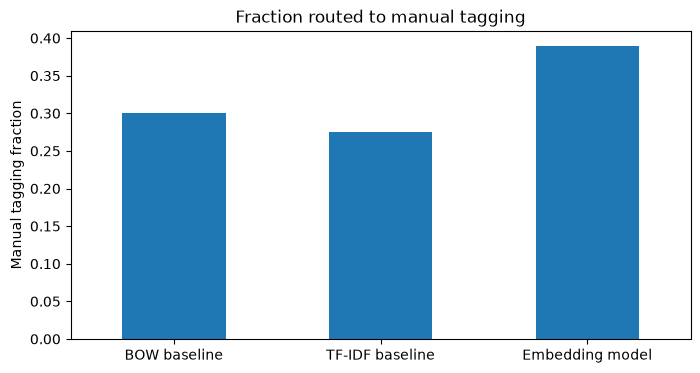

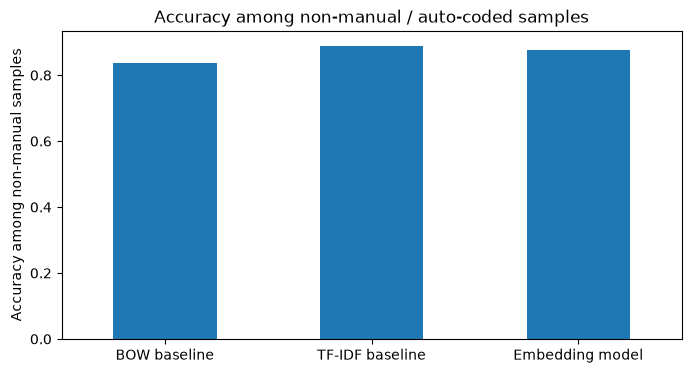

In [8]:
ax = operational_metrics["manual_tagging_fraction"].plot(
    kind="bar",
    figsize=(8, 4),
    title="Fraction routed to manual tagging"
)
ax.set_ylabel("Manual tagging fraction")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.show()

ax = operational_metrics["accuracy_among_non_manual"].plot(
    kind="bar",
    figsize=(8, 4),
    title="Accuracy among non-manual / auto-coded samples"
)
ax.set_ylabel("Accuracy among non-manual samples")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.show()

## 5. Additional model metrics

This table keeps the broader diagnostics available, but it is secondary to the operational metrics above.

In [9]:
model_comparison = compare_models(predictions_by_model)
display(model_comparison)

,n_samples,cv_type,effective_n_splits,singleton_exact_n,singleton_exact_fraction,non_singleton_n,manual_tagging_n,manual_tagging_fraction,auto_tagging_n,auto_tagging_fraction,safe_partial_accuracy_all,hierarchical_prefix_score_all,mean_predicted_digits,full_code_prediction_rate,manual_tagging_fraction_non_singleton,manual_tagging_fraction_singleton_exact,safe_partial_accuracy_non_singleton,safe_partial_accuracy_singleton_exact,accuracy_out_of_auto_tagged_samples,error_rate_out_of_auto_tagged_samples,mean_confidence_auto_tagged,accuracy_out_of_auto_tagged_non_singleton,accuracy_out_of_auto_tagged_singleton_exact,manual_safe_accuracy,mean_confidence_manual_tagged,auto_exact_accuracy_on_concrete_true,x_target_safety_rate,x_target_overspecific_rate,level_1_coverage,level_1_accuracy_when_predicted,level_2_coverage,level_2_accuracy_when_predicted,level_3_coverage,level_3_accuracy_when_predicted,level_4_coverage,level_4_accuracy_when_predicted
model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
BOW baseline,200,KFold,5,24,0.12,176,60,0.300,140,0.700,0.815,0.721,3.380,0.700,0.278,0.458,0.898,0.208,0.836,0.164,0.903,0.921,0.0,0.767,0.677,0.854,0.111,0.889,0.935,0.891,0.900,0.850,0.845,0.841,0.700,0.854
TF-IDF baseline,200,KFold,5,24,0.12,176,55,0.275,145,0.725,0.840,0.768,3.435,0.725,0.250,0.458,0.949,0.042,0.890,0.110,0.899,0.977,0.0,0.709,0.794,0.896,0.556,0.333,0.965,0.895,0.915,0.867,0.830,0.867,0.725,0.896
Embedding model,200,KFold,5,24,0.12,176,78,0.390,122,0.610,0.790,0.652,3.125,0.610,0.352,0.667,0.841,0.417,0.877,0.123,0.780,0.939,0.0,0.654,0.512,0.884,0.111,0.778,0.865,0.847,0.850,0.840,0.800,0.833,0.610,0.884


## 6. Feature importance plots

CatBoost is trained separately for each hierarchy level and CV fold. These plots show the average importance across all folds and hierarchy levels.

The feature list is still small and controlled. The raw text fields are converted into the four similarity features for modeling; the original text columns are shown later only for error analysis.

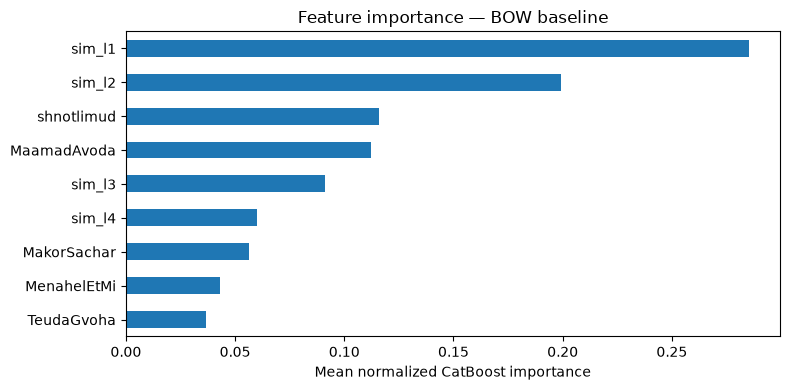

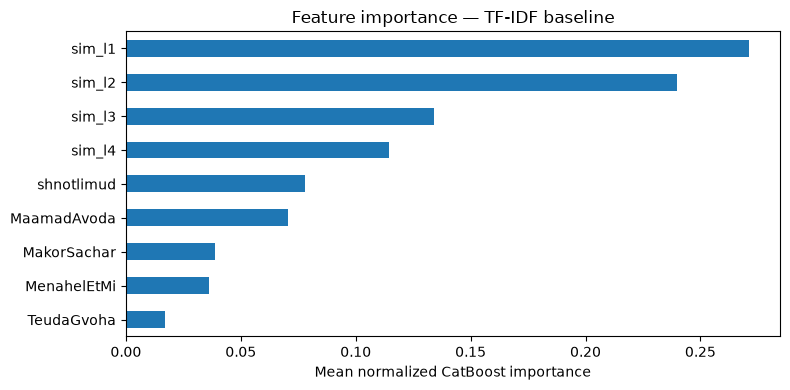

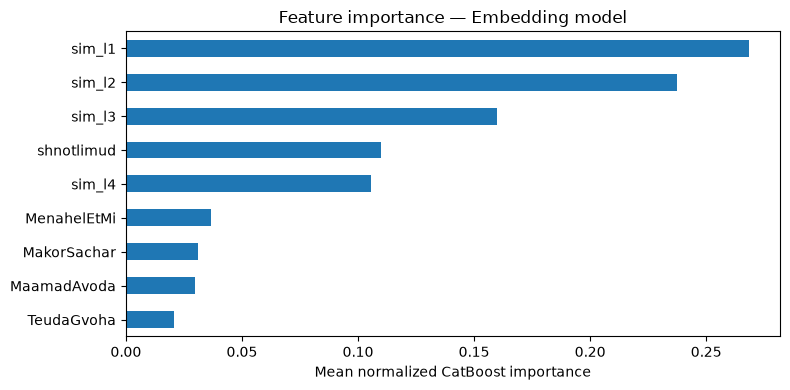

In [10]:
feature_importance_by_model = {
    "BOW baseline": bow_feature_importance,
    "TF-IDF baseline": tfidf_feature_importance,
    "Embedding model": embedding_feature_importance,
}


def plot_feature_importance(summary, title):
    values = (
        summary.set_index("feature")["importance_normalized_mean"]
        .reindex(MODEL_FEATURES)
        .fillna(0)
        .sort_values()
    )

    ax = values.plot(kind="barh", figsize=(8, 4), title=title)
    ax.set_xlabel("Mean normalized CatBoost importance")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


for model_name, importance_df in feature_importance_by_model.items():
    summary = summarize_feature_importance(importance_df)
    plot_feature_importance(summary, f"Feature importance — {model_name}")

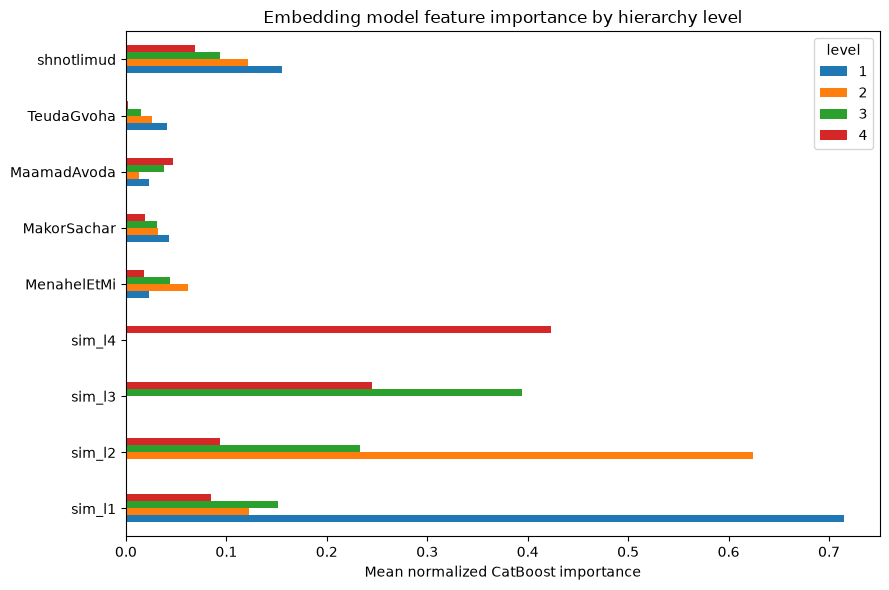

In [11]:
# By-level feature importance for the main embedding model.
# This helps check whether the model relies on different features for coarse vs. detailed coding.
embedding_importance_by_level = summarize_feature_importance_by_level(embedding_feature_importance)
embedding_importance_pivot = (
    embedding_importance_by_level
    .pivot(index="feature", columns="level", values="importance_normalized_mean")
    .reindex(MODEL_FEATURES)
    .fillna(0)
)

ax = embedding_importance_pivot.plot(
    kind="barh",
    figsize=(9, 6),
    title="Embedding model feature importance by hierarchy level",
)
ax.set_xlabel("Mean normalized CatBoost importance")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 7. Misclassified non-singleton, non-manual examples

For each model, the next cell samples mistakes where:

- the model made a non-manual prediction;
- the prediction was not safe/correct;
- the true exact class is not a full-dataset singleton.

For each sampled mistake, the notebook prints:

1. the misclassified row;
2. rows from the predicted wrong class/prefix;
3. rows from the true right class.

The displayed columns use the original text fields plus the selected tabular fields. The similarity columns `sim_l1`–`sim_l4` are intentionally not displayed here because they are derived features, not human-readable input fields.

In [12]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 220)

for model_name, pred in predictions_by_model.items():
    print("\n" + "=" * 100)
    print(model_name)

    comparisons = get_misclassification_class_comparisons(
        predictions=pred,
        records=records,
        model_name=model_name,
        n_cases=MISCLASSIFIED_SAMPLE_SIZE,
        # None means: show all rows in the sampled predicted/true class groups.
        # Change to REFERENCE_ROWS_PER_CLASS if the output is too long.
        max_rows_per_group=None,
        random_state=RANDOM_STATE,
    )

    if not comparisons:
        print("No matching non-singleton, non-manual misclassified examples.")
        continue

    for comp in comparisons:
        print("\n" + "-" * 100)
        print(
            f"Case {comp['case_number']}: true={comp['true_code']} | "
            f"predicted={comp['predicted_code']} | predicted_depth={comp['predicted_depth']}"
        )

        print("\nMisclassified row")
        display(comp["case_row"])

        print("\nRows from predicted wrong class/prefix")
        if comp["predicted_wrong_class_rows"].empty:
            print("No rows found for the predicted class/prefix in the reference data.")
        else:
            display(comp["predicted_wrong_class_rows"])

        print("\nRows from true right class")
        display(comp["true_right_class_rows"])


BOW baseline

----------------------------------------------------------------------------------------------------
Case 1: true=7414 | predicted=7127 | predicted_depth=4

Misclassified row


,model,case_number,row_role,predicted_code,predicted_depth,model_confidence,diagnostic_bucket,ID,SemelMishlachSofi,target_l1,target_l2,target_l3,target_l4,ShemAvoda,SugAvoda,ShemMachlaka,SugMachlaka,EzoAvoda,TeurPeula,TeurTafkid,MenahelEtMi,MakorSachar,MaamadAvoda,TeudaGvoha,shnotlimud
30,BOW baseline,1,MISCLASSIFIED_CASE,7127,4,0.957474,unsafe_and_sparse_true_exact,31.0,7414,7,74,741,7414,סולל בונה,אתר בניה אצל קבלן,עבודות חשמל,NaN,התקנת חשמל בדירות חדשות,עוזר לחשמלאי,NaN,0.0,2.0,1.0,3.0,12.0



Rows from predicted wrong class/prefix


,row_role,case_number,case_predicted_code,case_true_code,ID,SemelMishlachSofi,target_l1,target_l2,target_l3,target_l4,ShemAvoda,SugAvoda,ShemMachlaka,SugMachlaka,EzoAvoda,TeurPeula,TeurTafkid,MenahelEtMi,MakorSachar,MaamadAvoda,TeudaGvoha,shnotlimud
62,PREDICTED_WRONG_CLASS_ROW,1,7127,7414,63.0,7127,7,71,712,7127,סולל בונה,אתר בנייה,התקנת מזגנים,NaN,התקנת מזגנים בדירות חדשות,טכנאי מזגנים,NaN,0.0,2.0,1.0,3.0,12.0
125,PREDICTED_WRONG_CLASS_ROW,1,7127,7414,126.0,7127,7,71,712,7127,סולל בונה,אתר בנייה,התקנת מזגנים,NaN,התקנת מזגנים בדירות חדשות,טכנאי מזגנים,NaN,0.0,2.0,1.0,3.0,12.0
159,PREDICTED_WRONG_CLASS_ROW,1,7127,7414,160.0,7127,7,71,712,7127,אדרים,קבלן בנייה,התקנת מזגנים,NaN,התקנת מזגנים בדירות חדשות,טכנאי מזגנים,NaN,0.0,2.0,1.0,3.0,12.0



Rows from true right class


...

,model,case_number,row_role,predicted_code,predicted_depth,model_confidence,diagnostic_bucket,ID,SemelMishlachSofi,target_l1,target_l2,target_l3,target_l4,ShemAvoda,SugAvoda,ShemMachlaka,SugMachlaka,EzoAvoda,TeurPeula,TeurTafkid,MenahelEtMi,MakorSachar,MaamadAvoda,TeudaGvoha,shnotlimud
140,Embedding model,5,MISCLASSIFIED_CASE,5230,4,0.895921,unsafe_and_sparse_true_exact,141.0,2262,2,22,226,2262,רשת בי פארם,רוקח,רוקח,רוקח,רוקח,NaN,NaN,0.0,1.0,1.0,5.0,16.0



Rows from predicted wrong class/prefix


,row_role,case_number,case_predicted_code,case_true_code,ID,SemelMishlachSofi,target_l1,target_l2,target_l3,target_l4,ShemAvoda,SugAvoda,ShemMachlaka,SugMachlaka,EzoAvoda,TeurPeula,TeurTafkid,MenahelEtMi,MakorSachar,MaamadAvoda,TeudaGvoha,shnotlimud
8,PREDICTED_WRONG_CLASS_ROW,5,5230,2262,9.0,5230,5,52,523,5230,שופר סל,קופאית,NaN,NaN,קופאית,NaN,NaN,0.0,3.0,1.0,2.0,11.0
39,PREDICTED_WRONG_CLASS_ROW,5,5230,2262,40.0,5230,5,52,523,5230,שופרסל,סופר,NaN,NaN,קופאית,NaN,NaN,0.0,3.0,1.0,2.0,11.0
71,PREDICTED_WRONG_CLASS_ROW,5,5230,2262,72.0,5230,5,52,523,5230,שופר סל,קופאית,NaN,NaN,קופאית,NaN,NaN,0.0,3.0,1.0,2.0,11.0
102,PREDICTED_WRONG_CLASS_ROW,5,5230,2262,103.0,5230,5,52,523,5230,שופר סל,קופאית,NaN,NaN,קופאית,NaN,NaN,0.0,3.0,1.0,2.0,11.0
162,PREDICTED_WRONG_CLASS_ROW,5,5230,2262,163.0,5230,5,52,523,5230,רמי לוי,קופאי,NaN,NaN,קופאי,NaN,NaN,0.0,3.0,1.0,2.0,11.0
177,PREDICTED_WRONG_CLASS_ROW,5,5230,2262,178.0,5230,5,52,523,5230,רמי לוי,קופאית,NaN,NaN,קופאית,NaN,NaN,0.0,1.0,1.0,1.0,12.0



Rows from true right class


,row_role,case_number,case_predicted_code,case_true_code,ID,SemelMishlachSofi,target_l1,target_l2,target_l3,target_l4,ShemAvoda,SugAvoda,ShemMachlaka,SugMachlaka,EzoAvoda,TeurPeula,TeurTafkid,MenahelEtMi,MakorSachar,MaamadAvoda,TeudaGvoha,shnotlimud
134,TRUE_RIGHT_CLASS_ROW,5,5230,2262,135.0,2262,2,22,226,2262,סופרפארם,רוקח,רוקח,רוקח,רוקח,NaN,NaN,0.0,1.0,1.0,5.0,16.0
140,MISCLASSIFIED_CASE_IN_TRUE_CLASS,5,5230,2262,141.0,2262,2,22,226,2262,רשת בי פארם,רוקח,רוקח,רוקח,רוקח,NaN,NaN,0.0,1.0,1.0,5.0,16.0


## 8. Prediction outputs

The notebook saves prediction files and the most important summaries to CSV.

In [13]:
# Final prediction file for the main embedding model.
# This includes every record exactly once.
final_predictions = embedding_predictions[[
    ID_COL,
    TARGET_COL,
    "predicted_code",
    "predicted_depth",
    "needs_manual_tagging",
    "is_safe_prediction",
    "model_confidence",
    "diagnostic_bucket",
    "true_exact_support_bucket",
    "is_singleton_exact",
    "fold",
]].copy()

display(final_predictions.head())
print("Rows in final prediction file:", len(final_predictions))

,ID,SemelMishlachSofi,predicted_code,predicted_depth,needs_manual_tagging,is_safe_prediction,model_confidence,diagnostic_bucket,true_exact_support_bucket,is_singleton_exact,fold
0,1.0,2120,2120,4,False,True,0.716703,auto_tagged_safe,few_samples_in_training_fold,False,3
1,2.0,3311,3211,4,False,False,0.778195,unsafe_singleton_exact,absent_in_training_fold,True,5
2,3.0,3512,351X,3,True,True,0.663803,manual_tagging,few_samples_in_training_fold,False,3
3,4.0,5414,5414,4,False,True,0.857584,auto_tagged_safe,enough_samples_in_training_fold,False,4
4,5.0,5322,5322,4,False,True,0.581501,auto_tagged_safe,enough_samples_in_training_fold,False,3


Rows in final prediction file: 200


In [14]:
# operational_metrics.to_csv("model_operational_metrics.csv", encoding="utf-8-sig")
# model_comparison.to_csv("model_comparison_global_metrics.csv", encoding="utf-8-sig")

# bow_predictions.to_csv("bow_model_oof_predictions.csv", index=False, encoding="utf-8-sig")
# tfidf_predictions.to_csv("tfidf_model_oof_predictions.csv", index=False, encoding="utf-8-sig")
# embedding_predictions.to_csv("embedding_model_oof_predictions.csv", index=False, encoding="utf-8-sig")
# final_predictions.to_csv("embedding_model_final_predictions_by_record.csv", index=False, encoding="utf-8-sig")

# summarize_feature_importance(bow_feature_importance).to_csv("bow_model_feature_importance.csv", index=False, encoding="utf-8-sig")
# summarize_feature_importance(tfidf_feature_importance).to_csv("tfidf_model_feature_importance.csv", index=False, encoding="utf-8-sig")
# summarize_feature_importance(embedding_feature_importance).to_csv("embedding_model_feature_importance.csv", index=False, encoding="utf-8-sig")

# bow_feature_importance.to_csv("bow_model_feature_importance_raw.csv", index=False, encoding="utf-8-sig")
# tfidf_feature_importance.to_csv("tfidf_model_feature_importance_raw.csv", index=False, encoding="utf-8-sig")
# embedding_feature_importance.to_csv("embedding_model_feature_importance_raw.csv", index=False, encoding="utf-8-sig")

# for model_name, pred in predictions_by_model.items():
#     safe_name = model_name.lower().replace(" ", "_").replace("-", "")
#     sample = make_misclassification_comparison_sample(
#         predictions=pred,
#         records=records,
#         model_name=model_name,
#         n_cases=MISCLASSIFIED_SAMPLE_SIZE,
#         n_reference_rows=REFERENCE_ROWS_PER_CLASS,
#         random_state=RANDOM_STATE,
#     )
#     sample.to_csv(f"{safe_name}_misclassified_comparison_sample.csv", index=False, encoding="utf-8-sig")

# print("Saved CSV outputs:")
# print("- model_operational_metrics.csv")
# print("- model_comparison_global_metrics.csv")
# print("- bow_model_oof_predictions.csv")
# print("- tfidf_model_oof_predictions.csv")
# print("- embedding_model_oof_predictions.csv")
# print("- embedding_model_final_predictions_by_record.csv")
# print("- *_feature_importance.csv")
# print("- *_misclassified_comparison_sample.csv")

## 9. Notes for reproducibility

The project includes the precomputed embedding pickle to make the notebook easy to run. To recreate it, use:

```bash
python3 create_survey_embeddings_pickle.py --input DUMMY_DATASET.xlsx --output survey_with_embeddings.pkl
```

The pickle contains only `ID` and `embedding`, and the notebook merges embeddings by the original `ID` column.